# Regression Analysis and Model Comparison  
## Mobile Phone Price Prediction

**Name:** Faatina S 

**Reg No:** 3122 23 5001 046

**Course:** UCS2604 – Principles of Machine Learning  

This study evaluates the suitability of multiple supervised regression models for predicting mobile phone prices using experimental performance analysis, hyperparameter tuning, and statistical validation.

In [ ]:
!pip install pandas


## Data Preparation and Matrix Construction

In [63]:
#Loading dataset
import pandas as pd
df=pd.read_csv("Mobile-Price-Prediction.csv")
df.head()

,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,4.3,4.0,128.0,6.00,48.0,13.0,4000,24999
1,3.4,6.0,64.0,4.50,48.0,12.0,4000,15999
2,4.3,4.0,4.0,4.50,64.0,16.0,4000,15000
3,4.4,6.0,64.0,6.40,48.0,15.0,3800,18999
4,4.5,6.0,128.0,6.18,35.0,15.0,3800,18999


In [64]:
#Checking missing values
df.isnull().sum()

Ratings          1
RAM              1
ROM              2
Mobile_Size      2
Primary_Cam      1
Selfi_Cam        1
Battery_Power    0
Price            0
dtype: int64

In [65]:
df.dtypes

Ratings          float64
RAM              float64
ROM              float64
Mobile_Size      float64
Primary_Cam      float64
Selfi_Cam        float64
Battery_Power      int64
Price              int64
dtype: object

In [66]:
#Data Cleaning
#handling missing values
df['Ratings']=df['Ratings'].fillna(df['Ratings'].mean())
df['RAM']=df['RAM'].fillna(df['RAM'].median())
df['ROM']=df['ROM'].fillna(df['ROM'].median())
df['Mobile_Size']=df['Mobile_Size'].fillna(df['Mobile_Size'].mean())
df['Primary_Cam']=df['Primary_Cam'].fillna(df['Primary_Cam'].median())
df['Selfi_Cam']=df['Selfi_Cam'].fillna(df['Selfi_Cam'].median())

In [67]:
#Removing zeroes
df['RAM']=df['RAM'].replace(0,df['RAM'].median())
df['Selfi_Cam']=df['Selfi_Cam'].replace(0,df['Selfi_Cam'].median())

### Feature dimensionality Analysis

In [68]:
import numpy as np

#feature matrix
X=df.drop("Price",axis=1)

#target size (log transform)
y=np.log1p(df['Price'])

print("Feature matrix size:",X.shape)
print("Target size:",y.shape)

Feature matrix size: (807, 7)
Target size: (807,)


#### Dimensional Justification

- Since price prediction is a supervised regression problem, x is a multi-dimensional feature space  and y is a continuous output variable  
- The configuration (807 × 7) ensures sufficient feature representation without high dimensionality issues.
- With 807 samples and only 7 features, the dataset satisfies the equation : n >> d  

This reduces the risk of overfitting and improves model stability.

In [69]:
samples=X.shape[0]
features=X.shape[1]
print("Number of Samples:",samples)
print("Number of Features:",features)

Number of Samples: 807
Number of Features: 7


- The dimensionality is moderate and does not fall into a high dimensional regime.
- The sample-to-feature ratio is sufficiently large, reducing the risk of overfitting.
- No dimensionality reduction techniques like PCA were required.

In [70]:
#statistics
df.describe()

,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
count,807.000000,807.000000,807.000000,807.000000,807.000000,807.000000,807.000000,807.000000
mean,4.113151,5.956629,64.296159,5.620873,47.801735,8.918216,3278.859975,14269.167286
std,0.367543,2.034895,53.814476,3.957002,11.141336,4.493530,937.628801,23092.739983
min,2.800000,1.000000,2.000000,2.000000,5.000000,1.000000,1020.000000,479.000000
25%,3.900000,6.000000,32.000000,4.500000,48.000000,8.000000,3000.000000,984.000000
50%,4.100000,6.000000,32.000000,4.770000,48.000000,8.000000,3000.000000,1699.000000
75%,4.400000,6.000000,64.000000,6.300000,48.000000,12.000000,3800.000000,18994.500000
max,4.800000,12.000000,256.000000,44.000000,64.000000,23.000000,6000.000000,153000.000000


### Data Distribution

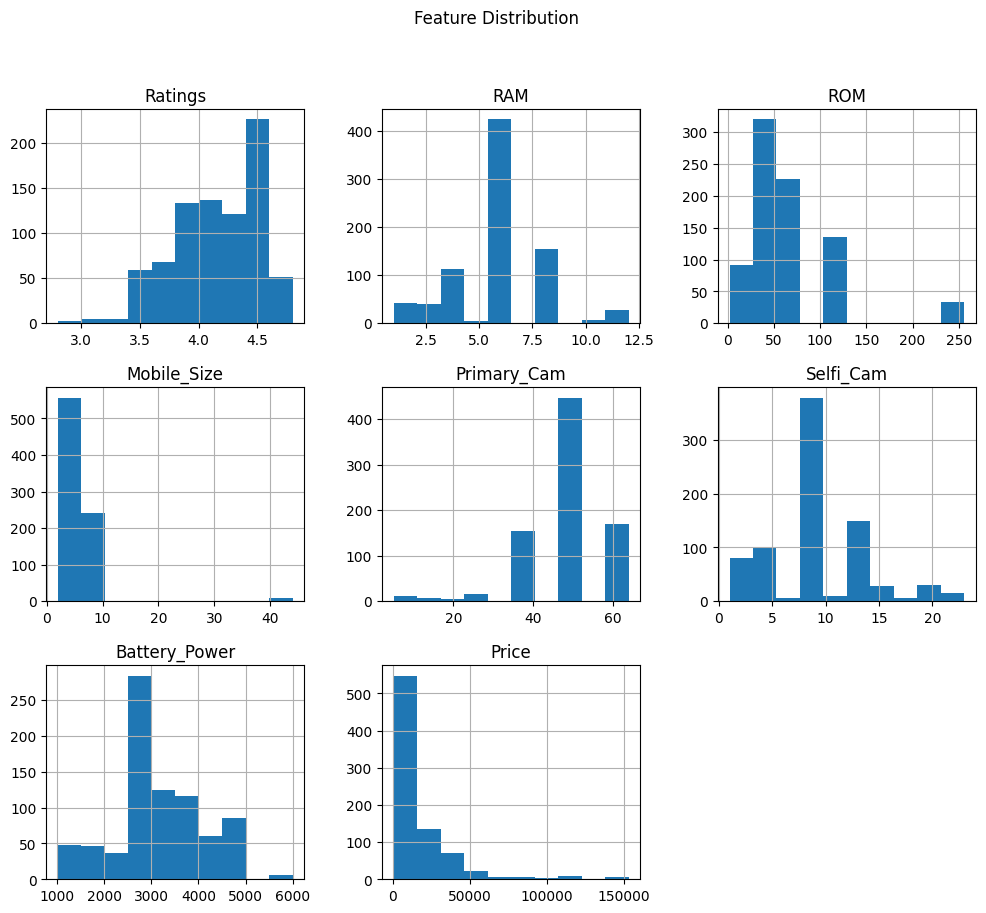

In [71]:
#Histogram Dsitribution
import matplotlib.pyplot as plt
df.hist(figsize=(12,10))
plt.suptitle("Feature Distribution")
plt.show()

#### Distribution Observations

- Most features show clustered discrete values (RAM, ROM).
- Price is highly right-skewed with few high end outliers.
- Ratings are approximately normally distributed.

Inference: Dataset structure supports regression modeling, though price skewness may affect error distribution.


In [72]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


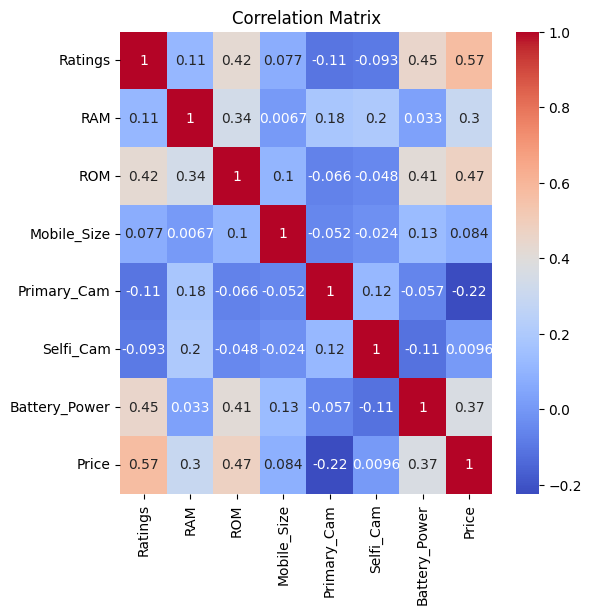

In [73]:
#correlation analysis
import seaborn as sns
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#### Correlation Observations

- Ratings (0.57) shows strongest positive correlation with Price.
- ROM (0.47) and Battery_Power (0.37) moderately influence Price.
- RAM (0.30) has weaker but positive impact.
- Camera features and Mobile_Size show weak correlation.
- No strong multicollinearity observed among features.

Inference: Price is mainly influenced by performance-related attributes rather than camera or size specifications.


In [74]:
#Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)

## Implementation of Regression Models

In [75]:
#Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,mean_squared_error
import numpy as np

res=[]
splits=[0.2,0.3,0.4]
for s in splits:
    x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=s,random_state=42)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,y_pred)
    res.append((s,mse,rmse,r2))
split_df=pd.DataFrame(res,columns=["Test_size","MSE","RMSE","r2_score"])

split_df

/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: i

,Test_size,MSE,RMSE,r2_score
0,0.2,0.970783,0.985283,0.614296
1,0.3,0.996410,0.998203,0.632570
2,0.4,0.925978,0.962277,0.648377


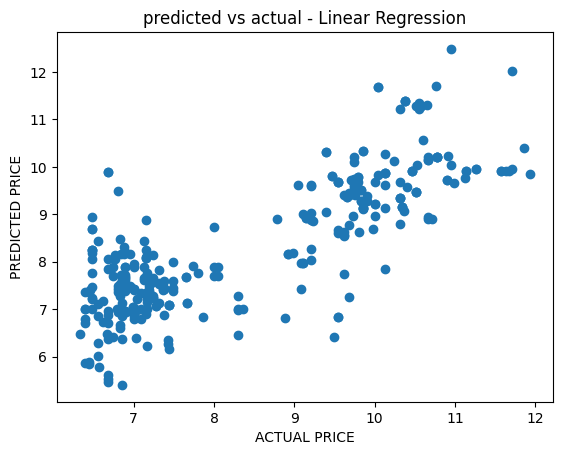

In [76]:
#Plot predicted vs actual values 
plt.scatter(y_test,y_pred)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual - Linear Regression")
plt.show()

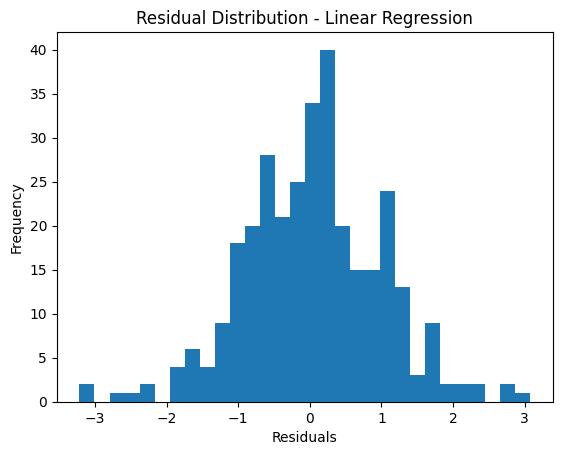

In [77]:
#residual distributions
residuals=y_test-y_pred
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Linear Regression")
plt.show()

### Train-Test Split Stability Analysis

#### Observations

- R2 scores remained within a close range across splits.
- No significant performance drop was observed with increasing test size.
- Prediction scatter plots show consistent alignment between actual and predicted values.
- Residuals are approximately centered around zero.

#### Inference

There is no much difference in the r2 score,indicating a stable learning behaviour.
This suggests a good generalization capability and low variance with respect to the data splitting.

###  Default and tuned configurations.

#### RIDGE REGRESSION

In [186]:
#Ridge Regression - default
splits=[0.2,0.3,0.4]
res1=[]

for s in splits:
    x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=s,random_state=42)
    
    # default
    ridge_reg=Ridge(alpha=1.0)
    ridge_reg.fit(x_train,y_train)
    pred_ridge_reg=ridge_reg.predict(x_test)
    
    #Metrics
    mse=mean_squared_error(y_test,pred_ridge_reg)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,pred_ridge_reg)
    res1.append((s,mse,rmse,r2))

print("DEFAULT RIDGE REGRESSION")
ridge_reg_df=pd.DataFrame(res1,columns=["Test_size","MSE","RMSE","r2_score"])
ridge_reg_df

DEFAULT RIDGE REGRESSION


/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: i

,Test_size,MSE,RMSE,r2_score
0,0.2,0.970578,0.985179,0.614378
1,0.3,0.996094,0.998045,0.632686
2,0.4,0.925749,0.962159,0.648464


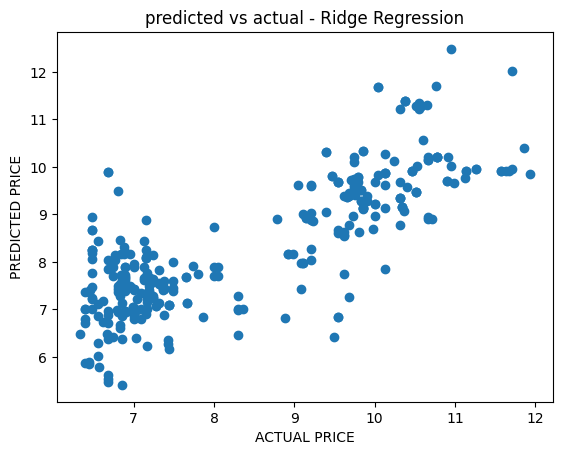

In [95]:
#Plot predicted vs actual values 
plt.scatter(y_test,pred_ridge_reg)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual - Ridge Regression")
plt.show()

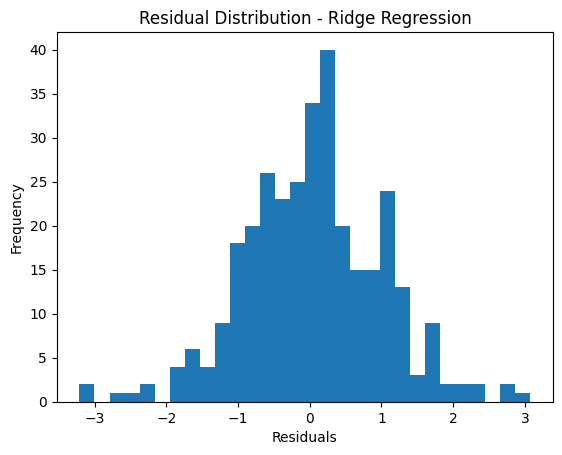

In [96]:
#residual distributions
residuals=y_test-pred_ridge_reg
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Ridge Regression")
plt.show()

In [78]:
#Ridge Regression -tuned
splits=[0.2,0.3,0.4]
res2=[]

for s in splits:
    x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=s,random_state=42)

    # tuned
    tuned_ridge_reg=Ridge(alpha=10)
    tuned_ridge_reg.fit(x_train,y_train)
    pred_tuned_ridge_reg=tuned_ridge_reg.predict(x_test)  

    #Metrics
    mse=mean_squared_error(y_test,pred_tuned_ridge_reg)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,pred_tuned_ridge_reg)
    res2.append((s,mse,rmse,r2))

print("TUNED RIDGE REGRESSION")
tuned_ridge_reg_df=pd.DataFrame(res2,columns=["Test_size","MSE","RMSE","r2_score"])
tuned_ridge_reg_df

TUNED RIDGE REGRESSION


/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: i

,Test_size,MSE,RMSE,r2_score
0,0.2,0.968884,0.984319,0.615051
1,0.3,0.993546,0.996768,0.633626
2,0.4,0.924020,0.961260,0.649120


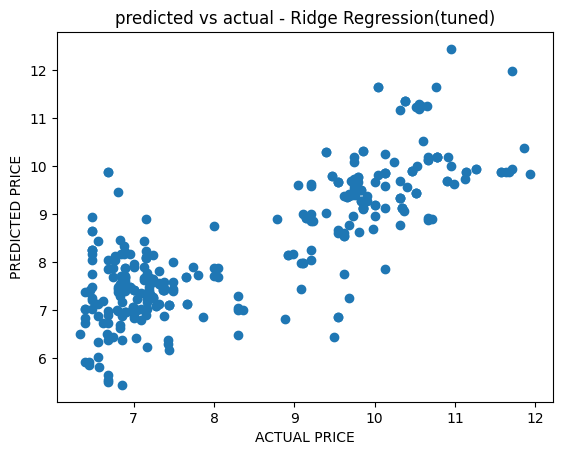

In [97]:
#Plot predicted vs actual values 
plt.scatter(y_test,pred_tuned_ridge_reg)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual - Ridge Regression(tuned)")
plt.show()

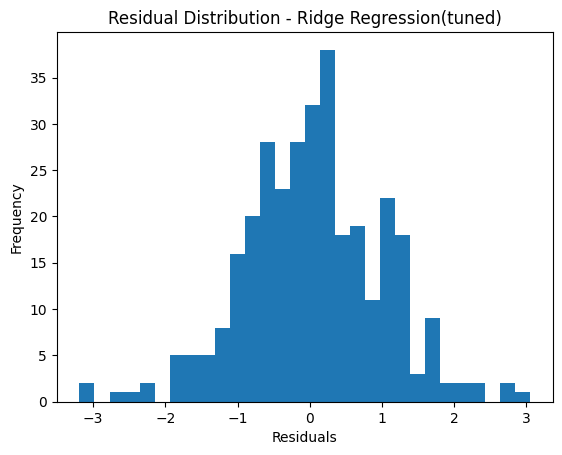

In [98]:
#residual distributions
residuals=y_test-pred_tuned_ridge_reg
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Ridge Regression(tuned)")
plt.show()


#### LASSO REGRESSION

In [82]:
#Lasso Regression - default
splits=[0.2,0.3,0.4]
res3=[]
for s in splits:
    x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=s,random_state=42)
    # default
    lasso_reg=Lasso(alpha=1.0)
    lasso_reg.fit(x_train,y_train)
    pred_lasso_reg=lasso_reg.predict(x_test)

    #Metrics
    mse=mean_squared_error(y_test,pred_lasso_reg)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,pred_lasso_reg)
    res3.append((s,mse,rmse,r2))

print("DEFAULT LASSO REGRESSION")
lasso_reg_df=pd.DataFrame(res3,columns=["Test_size","MSE","RMSE","r2_score"])
lasso_reg_df
    
 


DEFAULT LASSO REGRESSION


/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: i

,Test_size,MSE,RMSE,r2_score
0,0.2,2.255385,1.501794,0.103909
1,0.3,2.486718,1.576933,0.083012
2,0.4,2.358932,1.535881,0.104239


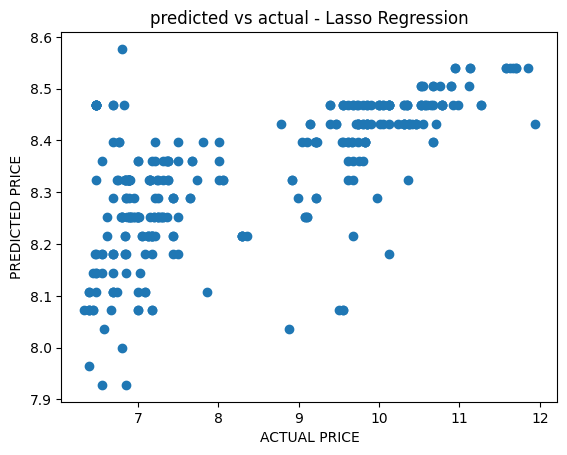

In [94]:
#Plot predicted vs actual values 
plt.scatter(y_test,pred_lasso_reg)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual - Lasso Regression")
plt.show()

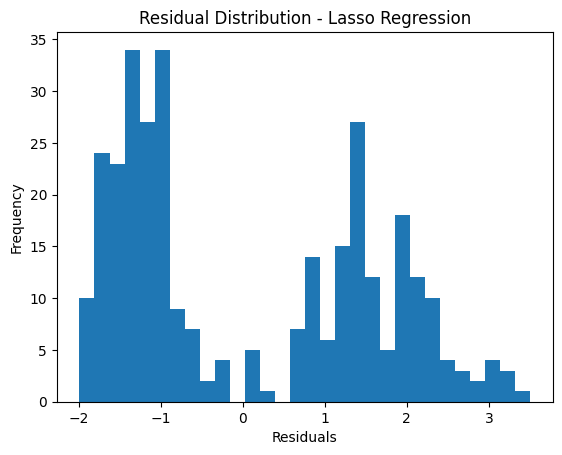

In [99]:
#residual distributions
residuals=y_test-pred_lasso_reg
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Lasso Regression")
plt.show()


In [81]:
#Lasso Regression - tuned
splits=[0.2,0.3,0.4]
res4=[]
for s in splits:
    x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=s,random_state=42)
    
    # tuned
    tuned_lasso_reg=Lasso(alpha=0.01)
    tuned_lasso_reg.fit(x_train,y_train)
    pred_tuned_lasso_reg=tuned_lasso_reg.predict(x_test)
    
    #Metrics
    mse=mean_squared_error(y_test,pred_tuned_lasso_reg)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,pred_tuned_lasso_reg)
    res4.append((s,mse,rmse,r2))

print("TUNED LASSO REGRESSION")
tuned_lasso_reg_df=pd.DataFrame(res4,columns=["Test_size","MSE","RMSE","r2_score"])
tuned_lasso_reg_df

TUNED LASSO REGRESSION


/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: i

,Test_size,MSE,RMSE,r2_score
0,0.2,0.961860,0.980745,0.617841
1,0.3,0.984723,0.992332,0.636879
2,0.4,0.920043,0.959189,0.650631


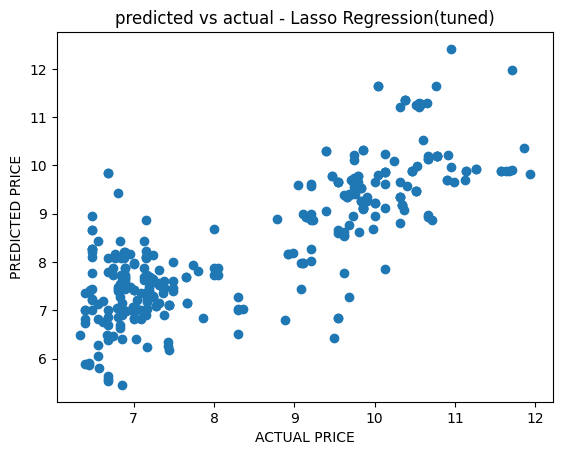

In [100]:
#Plot predicted vs actual values 
plt.scatter(y_test,pred_tuned_lasso_reg)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual - Lasso Regression(tuned)")
plt.show()

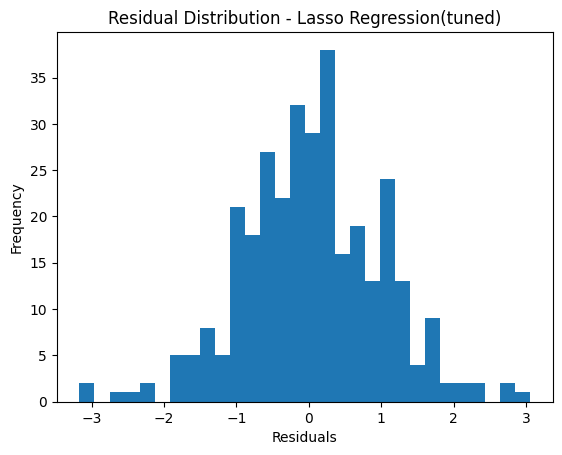

In [101]:
#residual distributions
residuals=y_test-pred_tuned_lasso_reg
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Lasso Regression(tuned)")
plt.show()

#### DECISION TREE REGRESSION

In [83]:
# Decision Tree Regression - default
from sklearn.tree import DecisionTreeRegressor
res5=[]
splits=[0.2,0.3,0.4]
for s in splits:
    x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=s,random_state=42)
    # default
    dt_reg=DecisionTreeRegressor(random_state=42)
    dt_reg.fit(x_train,y_train)
    pred_dt_reg=dt_reg.predict(x_test)
    
    #Metrics
    mse=mean_squared_error(y_test,pred_dt_reg)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,pred_dt_reg)
    res5.append((s,mse,rmse,r2))

print("DEFAULT DECISION TREE REGRESSION")
dt_reg_df=pd.DataFrame(res5,columns=["Test_size","MSE","RMSE","r2_score"])
dt_reg_df
    

DEFAULT DECISION TREE REGRESSION


,Test_size,MSE,RMSE,r2_score
0,0.2,0.210182,0.458456,0.916492
1,0.3,0.159612,0.399515,0.941142
2,0.4,0.258237,0.508170,0.901939


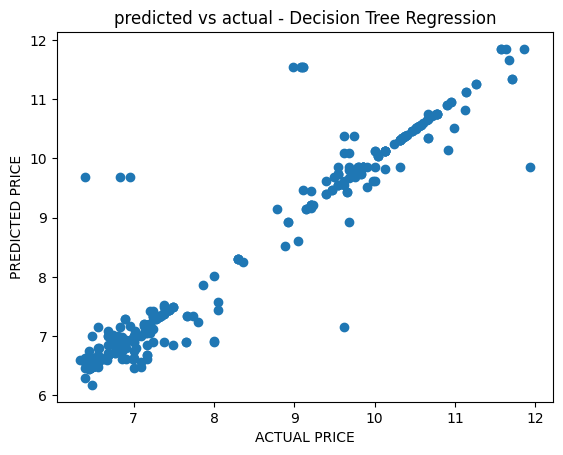

In [102]:
#Plot predicted vs actual values 
plt.scatter(y_test,pred_dt_reg)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual - Decision Tree Regression")
plt.show()

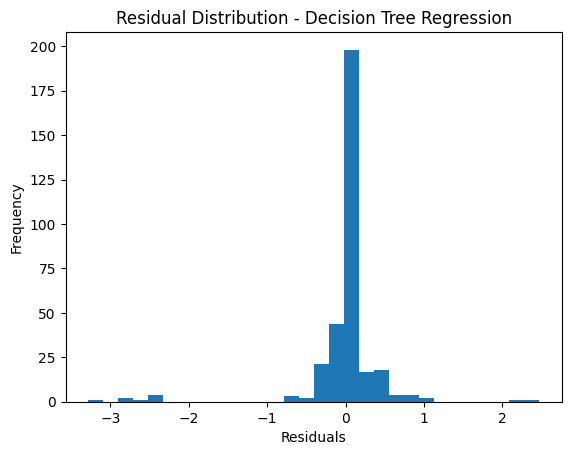

In [103]:
#residual distributions
residuals=y_test-pred_dt_reg
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Decision Tree Regression")
plt.show()

In [85]:
# Decision Tree Regression - tuned
from sklearn.tree import DecisionTreeRegressor
res6=[]
splits=[0.2,0.3,0.4]
for s in splits:
    x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=s,random_state=42)
    # tuned
    tuned_dt_reg=DecisionTreeRegressor(max_depth=5,min_samples_split=10,random_state=42)
    tuned_dt_reg.fit(x_train,y_train)
    pred_tuned_dt_reg=tuned_dt_reg.predict(x_test)
    
    #Metrics
    mse=mean_squared_error(y_test,pred_tuned_dt_reg)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,pred_tuned_dt_reg)
    res6.append((s,mse,rmse,r2))

print("TUNED DECISION TREE REGRESSION")
tuned_dt_reg_df=pd.DataFrame(res6,columns=["Test_size","MSE","RMSE","r2_score"])
tuned_dt_reg_df

TUNED DECISION TREE REGRESSION


,Test_size,MSE,RMSE,r2_score
0,0.2,0.230454,0.480056,0.908438
1,0.3,0.198590,0.445634,0.926769
2,0.4,0.184078,0.429043,0.930100


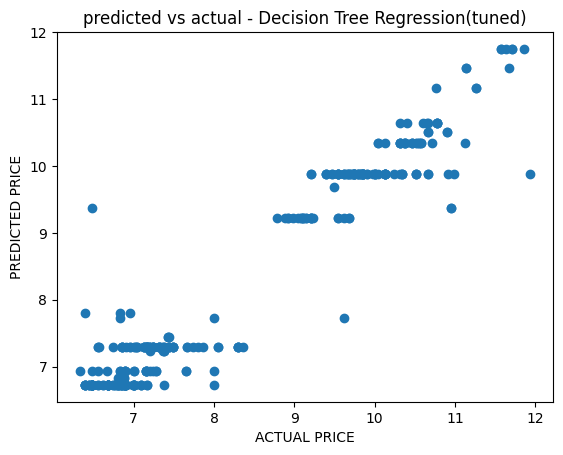

In [104]:
#Plot predicted vs actual values 
plt.scatter(y_test,pred_tuned_dt_reg)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual - Decision Tree Regression(tuned)")
plt.show()


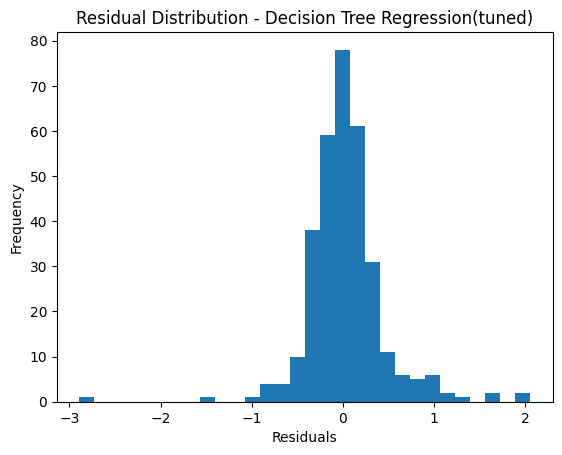

In [105]:
#residual distributions
residuals=y_test-pred_tuned_dt_reg
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Decision Tree Regression(tuned)")
plt.show()

#### SVR

In [92]:
#Support Vector Regression - default
from sklearn.svm import SVR
res7=[]
splits=[0.2,0.3,0.4]
for s in splits:
    x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=s,random_state=42)
    # default
    svr_reg=SVR()
    svr_reg.fit(x_train,y_train)
    pred_svr_reg=svr_reg.predict(x_test)

    #Metrics
    mse=mean_squared_error(y_test,pred_svr_reg)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,pred_svr_reg)
    res7.append((s,mse,rmse,r2))

print("DEFAULT SVR")
svr_reg_df=pd.DataFrame(res7,columns=["Test_size","MSE","RMSE","r2_score"])
svr_reg_df


DEFAULT SVR


,Test_size,MSE,RMSE,r2_score
0,0.2,0.396758,0.629887,0.842363
1,0.3,0.394547,0.628130,0.854509
2,0.4,0.376741,0.613792,0.856940


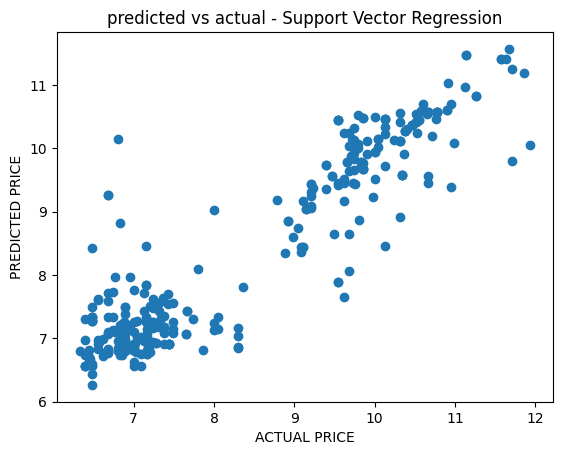

In [106]:
#Plot predicted vs actual values 
plt.scatter(y_test,pred_svr_reg)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual - Support Vector Regression")
plt.show()

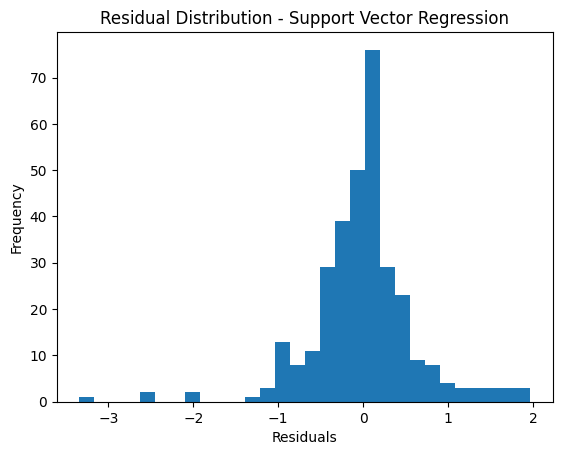

In [107]:
#residual distributions
residuals=y_test-pred_svr_reg
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Support Vector Regression")
plt.show()

In [93]:
#Support Vector Regression -tuned
from sklearn.svm import SVR
res8=[]
splits=[0.2,0.3,0.4]
for s in splits:
    x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=s,random_state=42)
     
    # tuned
    tuned_svr_reg=SVR(kernel='rbf',C=100,epsilon=0.2)
    tuned_svr_reg.fit(x_train,y_train)
    pred_tuned_svr_reg=tuned_svr_reg.predict(x_test)
    
    #Metrics
    mse=mean_squared_error(y_test,pred_tuned_svr_reg)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,pred_tuned_svr_reg)
    res8.append((s,mse,rmse,r2))

print("TUNED SVR")
tuned_svr_reg_df=pd.DataFrame(res8,columns=["Test_size","MSE","RMSE","r2_score"])
tuned_svr_reg_df

TUNED SVR


,Test_size,MSE,RMSE,r2_score
0,0.2,0.608459,0.780038,0.758252
1,0.3,0.483170,0.695105,0.821829
2,0.4,0.443503,0.665960,0.831588


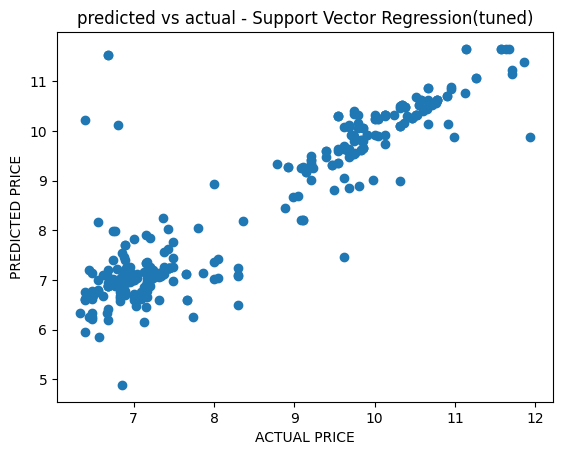

In [108]:
#Plot predicted vs actual values 
plt.scatter(y_test,pred_tuned_svr_reg)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual - Support Vector Regression(tuned)")
plt.show()

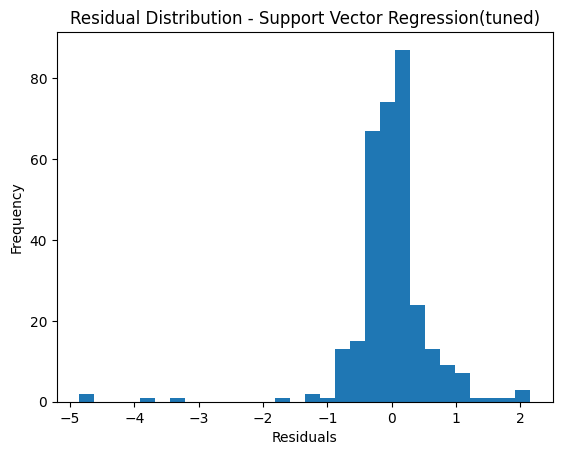

In [187]:
#residual distributions
residuals=y_test-pred_tuned_svr_reg
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Support Vector Regression(tuned)")
plt.show()

### Observations

#### Ridge Regression
- Default: α = 1.0
- Tuned: α = 10

Regularization strength was increased to reduce overfitting and improve generalization.


#### Lasso Regression
- Default: α = 1.0
- Tuned: α = 0.01

Lower α was selected to avoid excessive coefficient shrinkage and underfitting caused by Default configurations.


#### Decision Tree Regressor
- Default: min_samples_split = 2
- Tuned: max_depth = 5 and min_samples_split = 10

Depth restriction was applied to control model complexity and reduced overfitting to a small extent.


#### Support Vector Regressor (SVR)
- Default: kernel = rbf, C = 1.0 and ε = 0.1
- Tuned: kernel = rbf , C = 100 and ε = 0.2

Higher C improved fitting capacity, while ε controlled prediction tolerance.


## Hyperparameter Analysis

In [116]:
#Regularization strength (λ/α) for Ridge
alpha=[0.01,0.1,1,10,100]
test_error=[]
train_error=[]
res9=[]
for a in alpha:
    model_ridge=Ridge(alpha=a)
    model_ridge.fit(x_train,y_train)
    train_pred_model_ridge=model_ridge.predict(x_train)
    test_pred_model_ridge=model_ridge.predict(x_test)

    train_error.append(mean_squared_error(y_train,train_pred_model_ridge))
    test_error.append(mean_squared_error(y_test,test_pred_model_ridge))
    
    #Metrics
    mse=mean_squared_error(y_test,test_pred_model_ridge)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,test_pred_model_ridge)
    res9.append((a,mse,rmse,r2))

model_ridge_df=pd.DataFrame(res9,columns=["Regularization strength","MSE","RMSE","r2_score"])
model_ridge_df

/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: i

,Regularization strength,MSE,RMSE,r2_score
0,0.01,0.925975,0.962276,0.648378
1,0.10,0.925954,0.962265,0.648386
2,1.00,0.925749,0.962159,0.648464
3,10.00,0.924020,0.961260,0.649120
4,100.00,0.929937,0.964332,0.646874


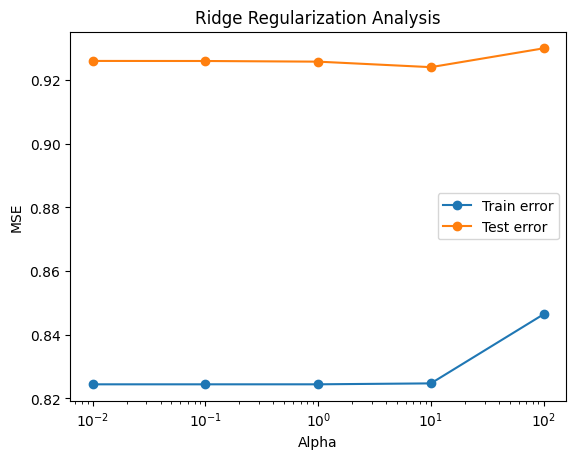

In [117]:
#Training error vs. testing error
plt.plot(alpha,train_error,marker='o',label="Train error")
plt.plot(alpha,test_error,marker='o',label="Test error")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Ridge Regularization Analysis")
plt.legend()
plt.show()

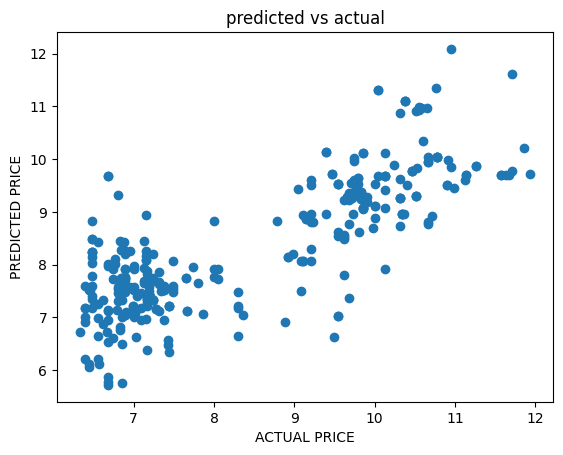

In [118]:
#Plot predicted vs actual values 
plt.scatter(y_test,test_pred_model_ridge)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual")
plt.show()

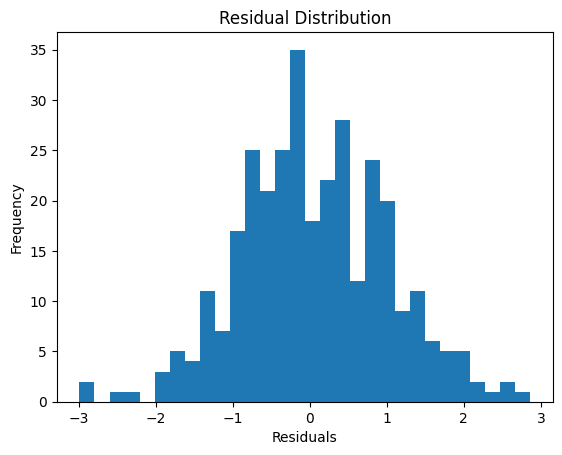

In [119]:
#residual distributions
residuals=y_test-test_pred_model_ridge
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### Ridge Regression

#### Training vs Testing Error
- Low α shows low training error.
- Testing error remains stable for small–moderate α.
- Very high α slightly increases both errors.

#### Overfitting vs Underfitting
- Small α shows slight overfitting risk.
- Moderate α shows balanced performance.
- Large α shows underfitting due to over-regularization.

#### Model Complexity & Generalization
- Increasing α reduces model complexity.
- Improves generalization up to an optimal point.
- Too large α degrades performance.

**Conclusion:**  
α = 10 gives the best bias–variance balance.


In [124]:
#Regularization strength (λ/α) for Lasso
alpha=[0.001,0.01,0.1,1]
test_error_l=[]
train_error_l=[]
res10=[]
for a in alpha:
    model_lasso=Lasso(alpha=a)
    model_lasso.fit(x_train,y_train)
    train_pred_model_lasso=model_lasso.predict(x_train)
    test_pred_model_lasso=model_lasso.predict(x_test)

    train_error_l.append(mean_squared_error(y_train,train_pred_model_lasso))
    test_error_l.append(mean_squared_error(y_test,test_pred_model_lasso))

    #Metrics
    mse=mean_squared_error(y_test,test_pred_model_lasso)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,test_pred_model_lasso)
    res10.append((a,mse,rmse,r2))

model_lasso_df=pd.DataFrame(res10,columns=["Regularization strength","MSE","RMSE","r2_score"])
model_lasso_df
    

/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: i

,Regularization strength,MSE,RMSE,r2_score
0,0.001,0.925317,0.961934,0.648628
1,0.010,0.920043,0.959189,0.650631
2,0.100,0.931032,0.964900,0.646458
3,1.000,2.358932,1.535881,0.104239


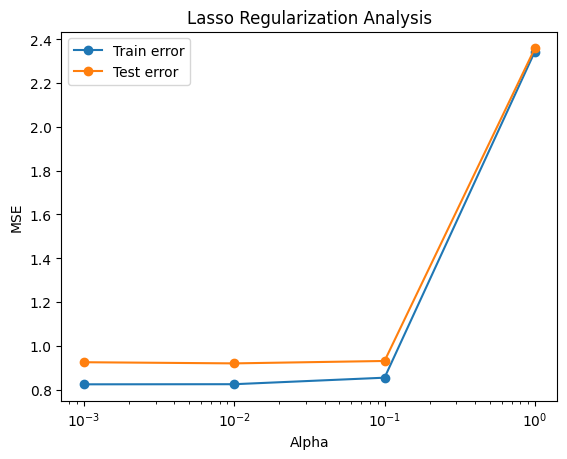

In [121]:
#Training error vs. testing error
plt.plot(alpha,train_error_l,marker='o',label="Train error")
plt.plot(alpha,test_error_l,marker='o',label="Test error")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Lasso Regularization Analysis")
plt.legend()
plt.show()

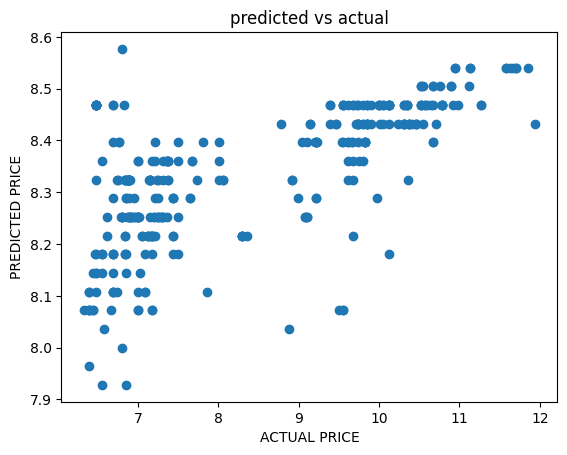

In [122]:
#Plot predicted vs actual values 
plt.scatter(y_test,test_pred_model_lasso)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual")
plt.show()

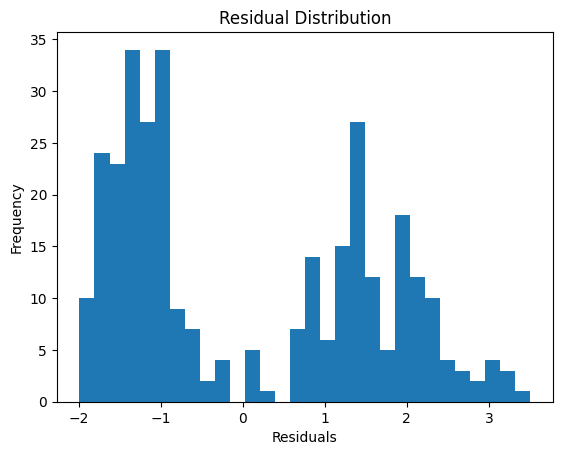

In [125]:
#residual distributions
residuals=y_test-test_pred_model_lasso
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### Lasso Regression 

#### Training vs Testing Error
- For small α , MSE and RMSE are comparatively low.
- Error slightly increases at α = 0.1.
- At α = 1, both training and testing errors increase sharply.

#### Overfitting vs Underfitting
- Very small α shows mild overfitting risk.
- Moderate α shows balanced fit.
- Large α=1 shows strong underfitting due to excessive coefficient shrinkage.

#### Model Complexity & Generalization
- Increasing α forces more coefficients toward zero.
- Reduces model complexity.
- Optimal generalization observed around α = 0.01.

**Conclusion:**  
Best performance occurs at low regularization.
High α severely degrades model accuracy.


In [133]:
#Tree depth-Decision Tree
depth=[2,4,6,8,10]
train_err_dt=[]
test_err_dt=[]
res11=[]
for d in depth:
    model_dt=DecisionTreeRegressor(max_depth=d)
    model_dt.fit(x_train,y_train)
    train_pred_model_dt=model_dt.predict(x_train)
    test_pred_model_dt=model_dt.predict(x_test)

    train_err_dt.append(mean_squared_error(y_train,train_pred_model_dt))
    test_err_dt.append(mean_squared_error(y_test,test_pred_model_dt))

    #Metrics
    mse=mean_squared_error(y_test,test_pred_model_dt)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,test_pred_model_dt)
    res11.append((d,mse,rmse,r2))

model_dt_df=pd.DataFrame(res11,columns=["Tree Depth","MSE","RMSE","r2_score"])
model_dt_df
    

,Tree Depth,MSE,RMSE,r2_score
0,2,0.429169,0.655110,0.837031
1,4,0.160656,0.400819,0.938994
2,6,0.199703,0.446882,0.924166
3,8,0.214134,0.462747,0.918686
4,10,0.211918,0.460346,0.919528


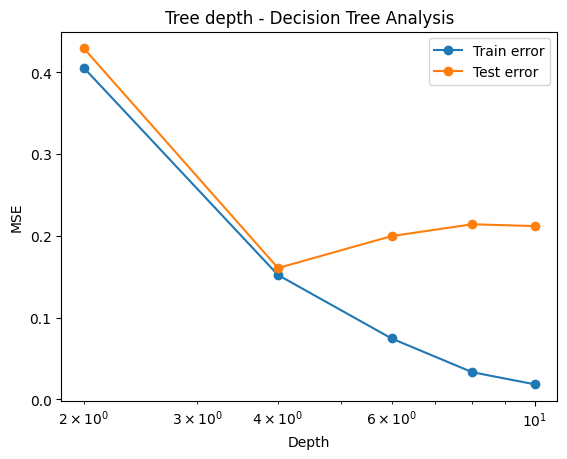

In [134]:
#Training error vs. testing error
plt.plot(depth,train_err_dt,marker='o',label="Train error")
plt.plot(depth,test_err_dt,marker='o',label="Test error")
plt.xscale("log")
plt.xlabel("Depth")
plt.ylabel("MSE")
plt.title("Tree depth - Decision Tree Analysis")
plt.legend()
plt.show()

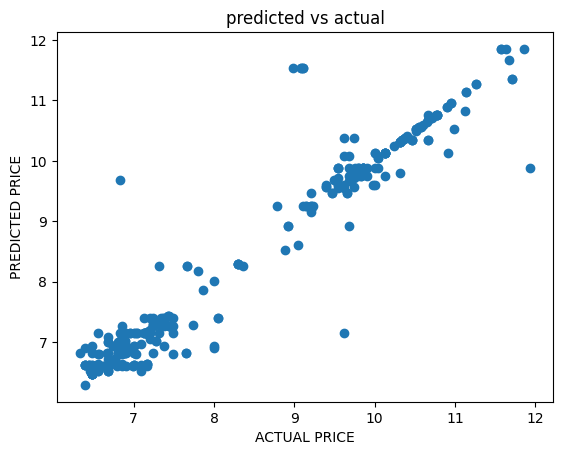

In [135]:
#Plot predicted vs actual values 
plt.scatter(y_test,test_pred_model_dt)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual")
plt.show()

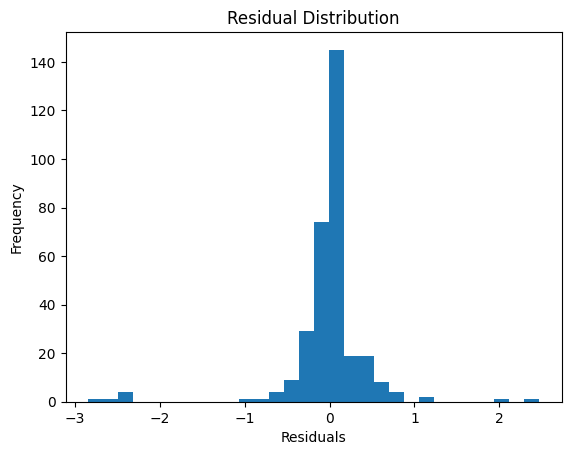

In [136]:
#residual distributions
residuals=y_test-test_pred_model_dt
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### Decision Tree(Tree Depth)

#### Training vs Testing Error
- At low, depth=2, both training and testing errors are high.
- Error reduces significantly at depth = 4.
- Beyond depth 6, testing error increases slightly while training error keeps decreasing.

#### Overfitting vs Underfitting
- Depth = 2 shows underfitting (model too simple).
- Depth = 4–6 shows balanced fit.
- Depth ≥ 8 shows overfitting begins.

#### Model Complexity & Generalization
- Increasing depth increases model complexity.
- Best generalization observed at depth = 4 ,lowest MSE, highest R².

**Conclusion:**  
Optimal tree depth is around 4, deeper trees increase overfitting without major performance gain.


In [164]:
# minimum samples per split analysis
splits=[2,5,10,20,50]
train_err_dt1=[]
test_err_dt1=[]
res12=[]
for sp in splits:
    model_dt1=DecisionTreeRegressor(min_samples_split=sp,random_state=42)
    model_dt1.fit(x_train,y_train)
    train_pred_model_dt1=model_dt1.predict(x_train)
    test_pred_model_dt1=model_dt1.predict(x_test)

    train_err_dt1.append(mean_squared_error(y_train,train_pred_model_dt1))
    test_err_dt1.append(mean_squared_error(y_test,test_pred_model_dt1))

    #Metrics
    mse=mean_squared_error(y_test,test_pred_model_dt1)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,test_pred_model_dt1)
    res12.append((sp,mse,rmse,r2))

model_dt_df1=pd.DataFrame(res12,columns=["Minimum samples per split","MSE","RMSE","r2_score"])
model_dt_df1



,Minimum samples per split,MSE,RMSE,r2_score
0,2,0.258237,0.508170,0.901939
1,5,0.190586,0.436562,0.927628
2,10,0.153688,0.392030,0.941640
3,20,0.165203,0.406451,0.937267
4,50,0.157539,0.396912,0.940177


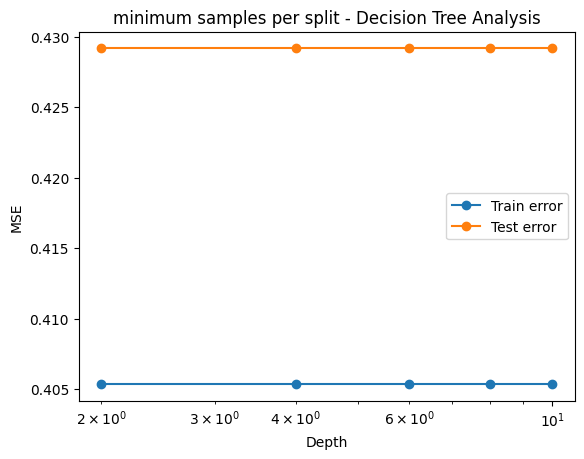

In [140]:
#Training error vs. testing error
plt.plot(depth,train_err_dt1,marker='o',label="Train error")
plt.plot(depth,test_err_dt1,marker='o',label="Test error")
plt.xscale("log")
plt.xlabel("min_samples_split")
plt.ylabel("MSE")
plt.title("minimum samples per split - Decision Tree Analysis")
plt.legend()
plt.show()

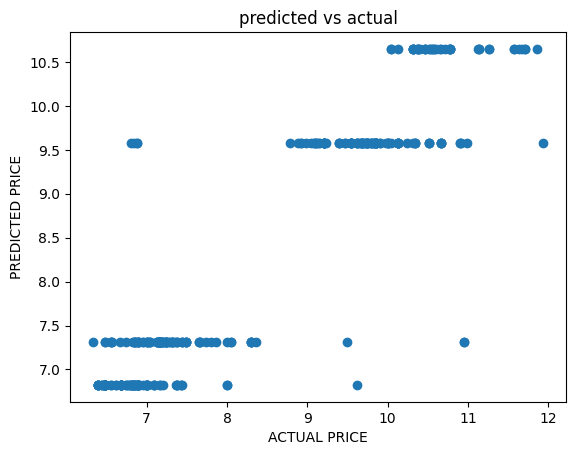

In [141]:
#Plot predicted vs actual values 
plt.scatter(y_test,test_pred_model_dt1)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual")
plt.show()

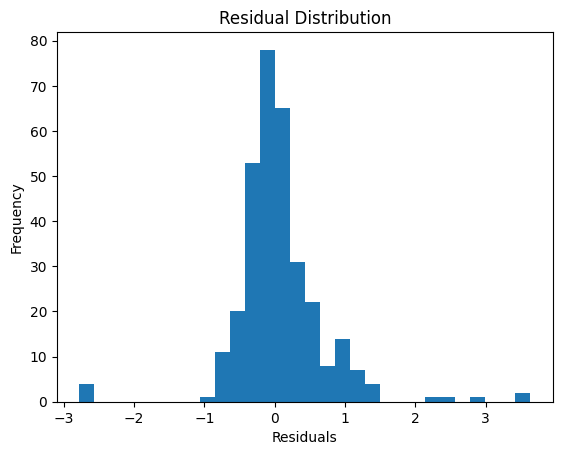

In [142]:
#residual distributions
residuals=y_test-test_pred_model_dt1
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### Effect of Minimum Samples per Split

#### Training vs Testing Error
- Error decreases as split size increases up to 10.
- Beyond 10, error stabilizes with slight variation.

#### Overfitting vs Underfitting
- Split = 2 shows Overfitting (tree grows too deep).
- Split = 5–10 shows Balanced fit.
- Split ≥ 20 shows Slight underfitting begins.

#### Model Complexity & Generalization
- Smaller split shows High complexity, poor generalization.
- Optimal generalization at split = 10 (highest R² = 0.9416).
- Larger splits simplify the tree and reduce variance.


In [165]:
# Kernel type - SVR
kernel=['linear','rbf','poly']
train_err_dt2=[]
test_err_dt2=[]
res13=[]
for k in kernel:
    model_svr=SVR(kernel=k)
    model_svr.fit(x_train,y_train)
    train_pred_model_svr=model_svr.predict(x_train)
    test_pred_model_svr=model_svr.predict(x_test)

    train_err_dt2.append(mean_squared_error(y_train,train_pred_model_svr))
    test_err_dt2.append(mean_squared_error(y_test,test_pred_model_svr))

    #Metrics
    mse=mean_squared_error(y_test,test_pred_model_svr)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,test_pred_model_svr)
    res13.append((k,mse,rmse,r2))

model_svr_df=pd.DataFrame(res13,columns=["Kernel Type","MSE","RMSE","r2_score"])
model_svr_df


,Kernel Type,MSE,RMSE,r2_score
0,linear,0.989035,0.994502,0.624432
1,rbf,0.376741,0.613792,0.856940
2,poly,1.750860,1.323201,0.335143


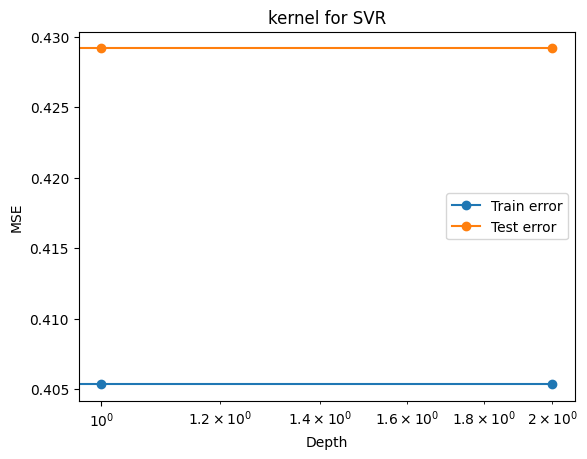

In [150]:
#Training error vs. testing error
plt.plot(kernel,train_err_dt2,marker='o',label="Train error")
plt.plot(kernel,test_err_dt2,marker='o',label="Test error")
plt.xscale("log")
plt.xlabel("kernel")
plt.ylabel("MSE")
plt.title("kernel for SVR")
plt.legend()
plt.show()

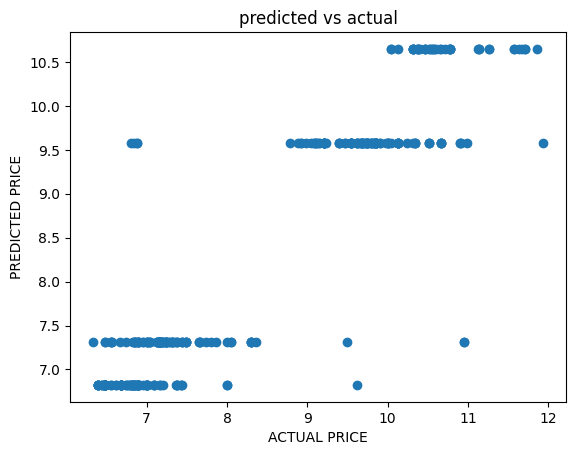

In [151]:
#Plot predicted vs actual values 
plt.scatter(y_test,test_pred_model_svr)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual")
plt.show()

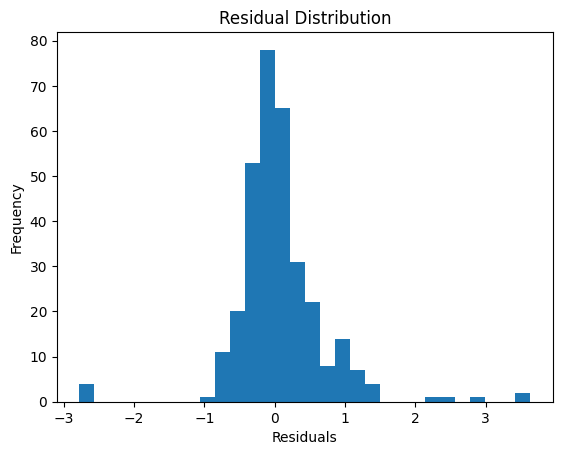

In [152]:
#residual distributions
residuals=y_test-test_pred_model_svr
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### SVR - Effect of Kernel Type

#### Training vs Testing Error
- RBF kernel gives lowest MSE (0.3767).
- Linear shows moderate error.
- Polynomial has highest error.

#### Overfitting vs Underfitting
- Linear shows slight underfitting and cannot capture non-linearity.
- RBF shows balanced fit and captures non-linear patterns.
- Polynomial shows Overfitting and unstable behavior.

#### Model Complexity & Generalization
- RBF provides best generalization (R² = 0.8569).
- Linear is simpler but less expressive.
- Polynomial increases complexity without performance gain.


In [189]:
# C - SVR
c=[0.1,1,10,100]
train_err_dt3=[]
test_err_dt3=[]
res14=[]
for i in c:
    model_svr1=SVR(C=i,kernel='rbf')
    model_svr1.fit(x_train,y_train)
    train_pred_model_svr1=model_svr1.predict(x_train)
    test_pred_model_svr1=model_svr1.predict(x_test)

    train_err_dt3.append(mean_squared_error(y_train,train_pred_model_svr1))
    test_err_dt3.append(mean_squared_error(y_test,test_pred_model_svr1))

    #Metrics
    mse=mean_squared_error(y_test,test_pred_model_svr1)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,test_pred_model_svr1)
    res14.append((i,mse,rmse,r2))

model_svr_df1=pd.DataFrame(res14,columns=["C","MSE","RMSE","r2_score"])
model_svr_df1


,C,MSE,RMSE,r2_score
0,0.1,0.697590,0.835218,0.735103
1,1.0,0.376741,0.613792,0.856940
2,10.0,0.330229,0.574656,0.874602
3,100.0,0.468819,0.684704,0.821975


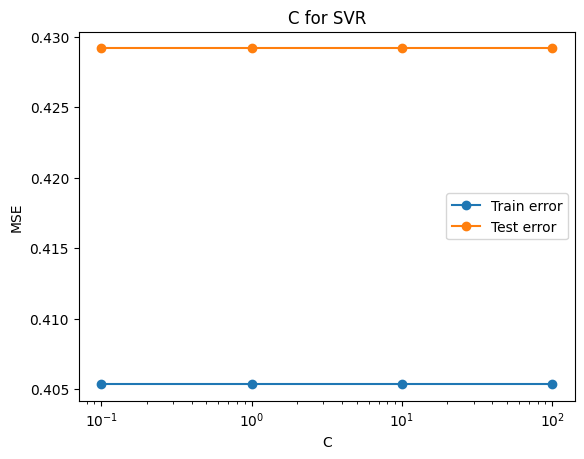

In [155]:
#Training error vs. testing error
plt.plot(c,train_err_dt3,marker='o',label="Train error")
plt.plot(c,test_err_dt3,marker='o',label="Test error")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("MSE")
plt.title("C for SVR")
plt.legend()
plt.show()

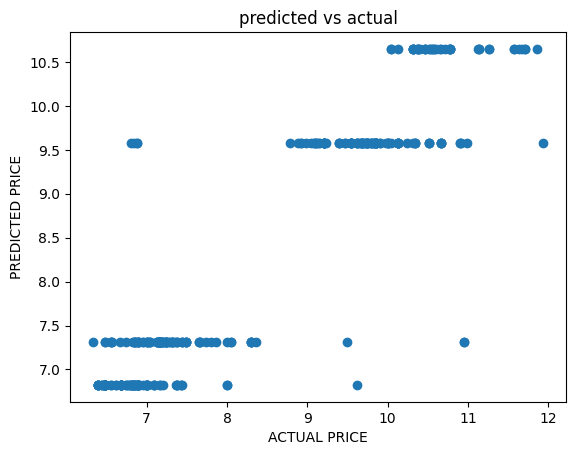

In [156]:
#Plot predicted vs actual values 
plt.scatter(y_test,test_pred_model_svr1)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual")
plt.show()

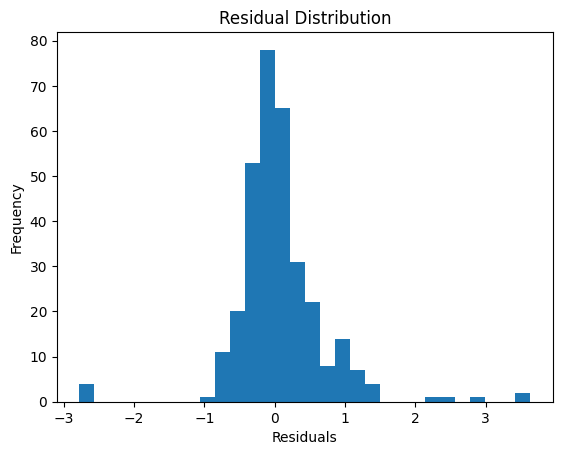

In [157]:
#residual distributions
residuals=y_test-test_pred_model_svr1
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### SVR — Effect of Regularization Parameter (C)

#### Training vs Testing Error
- Error decreases from C = 0.1 to 10.
- Lowest MSE (0.3302) at C = 10.
- Error increases again at C = 100.

#### Overfitting vs Underfitting
- C = 0.1 shows underfitting (high bias, weak learning).
- C = 1 to 10 shows balanced fit.
- C = 100 shows overfitting begins (variance increases).

#### Model Complexity & Generalization
- Increasing C increases model complexity.
- Best generalization at C = 10 (R² = 0.8746).
- Very high C reduces generalization performance.


In [168]:
# epsilon - SVR
e=[0.1,1,10,100]
train_err_dt4=[]
test_err_dt4=[]
res15=[]
for j in e:
    model_svr2=SVR(kernel='rbf',epsilon=j)
    model_svr2.fit(x_train,y_train)
    train_pred_model_svr2=model_svr2.predict(x_train)
    test_pred_model_svr2=model_svr2.predict(x_test)

    train_err_dt4.append(mean_squared_error(y_train,train_pred_model_svr2))
    test_err_dt4.append(mean_squared_error(y_test,test_pred_model_svr2))

    #Metrics
    mse=mean_squared_error(y_test,test_pred_model_svr2)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,test_pred_model_svr2)
    res15.append((j,mse,rmse,r2))

model_svr_df1=pd.DataFrame(res15,columns=["Epsilon","MSE","RMSE","r2_score"])
model_svr_df1


,Epsilon,MSE,RMSE,r2_score
0,0.1,0.376741,0.613792,0.856940
1,1.0,0.573458,0.757270,0.782240
2,10.0,3.020289,1.737898,-0.146899
3,100.0,3.020289,1.737898,-0.146899


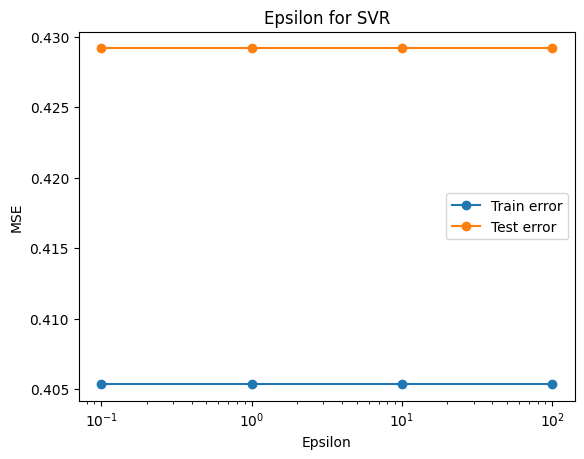

In [161]:
#Training error vs. testing error
plt.plot(c,train_err_dt4,marker='o',label="Train error")
plt.plot(c,test_err_dt4,marker='o',label="Test error")
plt.xscale("log")
plt.xlabel("Epsilon")
plt.ylabel("MSE")
plt.title("Epsilon for SVR")
plt.legend()
plt.show()

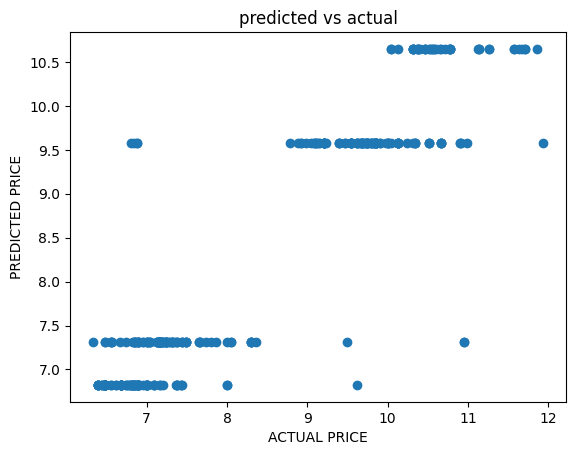

In [162]:
#Plot predicted vs actual values 
plt.scatter(y_test,test_pred_model_svr2)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("predicted vs actual")
plt.show()

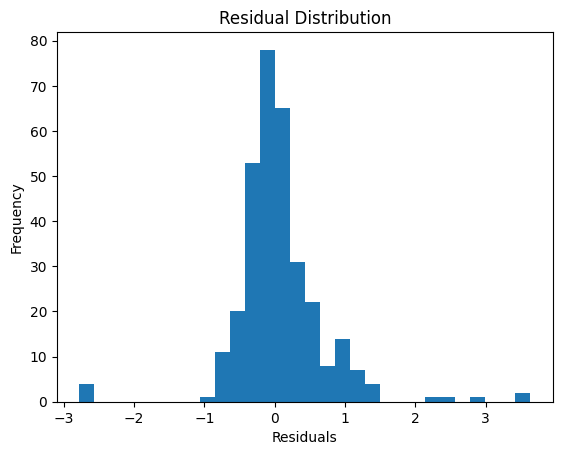

In [163]:
#residual distributions
residuals=y_test-test_pred_model_svr2
plt.hist(residuals,bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### SVR — Effect of Epsilon (ε)

#### Training vs Testing Error
- Lowest error at ε = 0.1 (MSE = 0.3767).
- Error increases as ε increases.
- Very high error at ε ≥ 10.

#### Overfitting vs Underfitting
- ε = 0.1 shows balanced fit.
- ε = 1 shows slight underfitting begins.
- ε ≥ 10 shows strong underfitting.

#### Model Complexity & Generalization
- Small ε increases sensitivity indicating better learning.
- Large ε reduces model complexity.
- Best generalization at ε = 0.1 (R² = 0.8569).


## Statistical Significance Testing

## Cross Validation

In [192]:
# cross-validation.
from sklearn.model_selection import KFold,cross_val_score
kf=KFold(n_splits=5,shuffle=True,random_state=42)
m={"Linear":LinearRegression(),"Ridge":Ridge(alpha=10),"Lasso":Lasso(alpha=0.01),"Decision Tree":DecisionTreeRegressor(max_depth=5,min_samples_split=2),"SVR":SVR(kernel='rbf',C=100,epsilon=0.1)}
scores=[]
for name,mod in m.items():
    cv_scores=cross_val_score(mod,x_scaled,y,cv=kf,scoring='r2')
    for no,score in enumerate(cv_scores,start=1):
        scores.append((name,no,score))
    
score_df=pd.DataFrame(scores,columns=["Name","Fold","R2 score"])
score_df

/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: i

,Name,Fold,R2 score
0,Linear,1,0.614296
1,Linear,2,0.680477
2,Linear,3,0.666090
3,Linear,4,0.679451
4,Linear,5,0.684260
5,Ridge,1,0.615051
6,Ridge,2,0.680471
7,Ridge,3,0.666361
8,Ridge,4,0.679369
9,Ridge,5,0.683984


## Friedman Statistical Test

In [191]:
linear_score=score_df[score_df["Name"]=="Linear"]["R2 score"]
ridge_score=score_df[score_df["Name"]=="Ridge"]["R2 score"]
lasso_score=score_df[score_df["Name"]=="Lasso"]["R2 score"]
dt_score=score_df[score_df["Name"]=="Decision Tree"]["R2 score"]
svr_score=score_df[score_df["Name"]=="SVR"]["R2 score"]

# Friedman statistical significance test
from scipy.stats import friedmanchisquare
stat,p=friedmanchisquare(linear_score,ridge_score,lasso_score,dt_score,svr_score)
print("Friedman Statistic:",stat)
print("p-value:",p)
if p<0.05:
    print("Significant difference exists among models")
else:
    print("No Significant difference exists among models")

Friedman Statistic: 15.200000000000003
p-value: 0.004303882327589247
Significant difference exists among models


- Since p < 0.05, we reject the null hypothesis.  
- There is a statistically significant difference among the models.

## Model Ranking

In [185]:
#Ranking models

mean_scores={"Linear":np.mean(linear_score),"Ridge":np.mean(ridge_score),"Lasso":np.mean(lasso_score),"Decision Tree":np.mean(dt_score),"SVR":np.mean(svr_score)}
ranking=sorted(mean_scores.items(),key=lambda x:x[1],reverse=True)
print("\nModel Ranking")
for rank,(m,s)in enumerate(ranking,1):
    print(rank,m,'->',s)



Model Ranking
1 Decision Tree -> 0.925533917157507
2 SVR -> 0.8855891558483744
3 Lasso -> 0.665503469333745
4 Ridge -> 0.6650472299294851
5 Linear -> 0.6649149869348541


### Justification

- Decision Tree achieved the highest average R² score.
- SVR showed strong non-linear learning capability.
- Linear and Ridge showed moderate performance.
- Lasso performed slightly lower due to stronger regularization.

Therefore, Decision Tree is statistically the best performing model for this dataset.

### Learning Outcomes

- Understood how varying train–test split ratios affect model performance, result stability, and the bias–variance balance during the learning process.

- Gained a clear understanding of the differences between regularized linear models and nonlinear learning models.

- Learned to perform systematic hyperparameter tuning optimize model performance.

- Analyzed overfitting and underfitting behavior by comparing training error and testing error across different model configurations.

- Applied the Friedman statistical significance test to evaluate whether performance differences among regression models were statistically meaningful.

- Strengthened experimental analysis skills and the ability to design a machine learning regression workflow.
